# Pipeline

Detect the cube in 2D, estimate 3D centroid from masked Open3D point cloud, compare to ground truth.

Run `setup.ipynb` first on Colab if Drive is not mounted.

## Setup

Mount Drive in Colab and install from `pyproject.toml` (`pip install -e .`).

In [1]:
import os
import runpy

_cwd = os.getcwd()
_utils = os.path.join(_cwd, "colab_utils.py")
if not os.path.isfile(_utils):
    _utils = os.path.join(_cwd, "notebooks", "colab_utils.py")
runpy.run_path(_utils)

from notebooks.colab_utils import enable_inline_matplotlib, install_requirements, setup_notebook

enable_inline_matplotlib()
PROJECT_ROOT = setup_notebook()
install_requirements(PROJECT_ROOT)

## Load frame

`load_frame` loads from disk in order: `isaac_exports/` → `gazebo_exports/` → `synthetic_exports/`. Watch the printed `source` field in frame metadata.

Frame source: synthetic_export


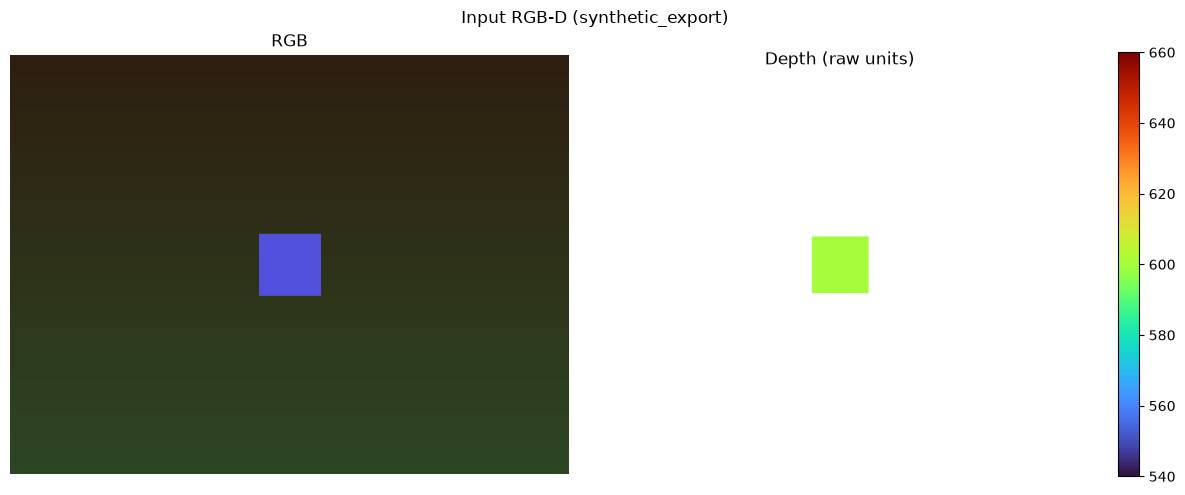

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from rgbd_pose.detection import ObjectDetector
from data.frame import load_frame
from rgbd_pose.pose import PoseEstimator
from evals.metrics import draw_detection, draw_3d_error, show_rgb_depth

frame = load_frame(PROJECT_ROOT)
rgb, depth, intrinsics, gt_pose, source = (
    frame.rgb,
    frame.depth,
    frame.intrinsics,
    frame.gt_pose,
    frame.source,
)
print(f"Frame source: {source}")
show_rgb_depth(rgb, depth, title=f"Input RGB-D ({source})")

## 2D detection

HSV threshold + largest contour. Default range is for a blue-ish cube — adjust `hsv_lower` / `hsv_upper` if detection fails.

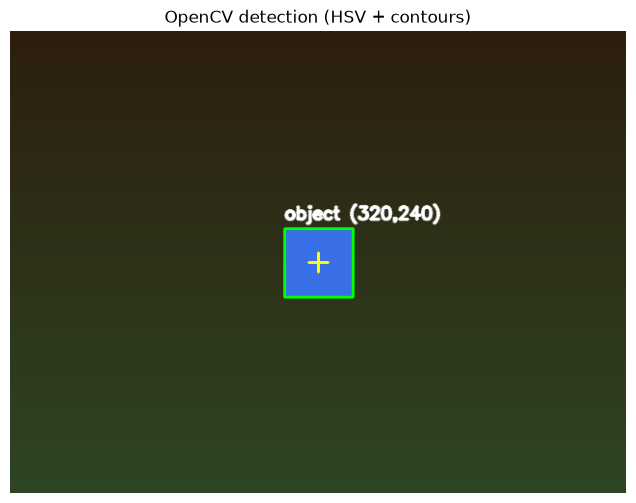

Center pixel: (320, 240), area: 4894px


In [3]:
detector = ObjectDetector(hsv_lower=(100, 80, 80), hsv_upper=(130, 255, 255))
detection = detector.detect(rgb)

vis_det = draw_detection(rgb, detection)
plt.figure(figsize=(8, 6))
plt.imshow(vis_det)
plt.title("OpenCV detection (HSV + contours)")
plt.axis("off")
plt.show()

if detection:
    print(f"Center pixel: {detection.center_px}, area: {detection.contour_area:.0f}px")
else:
    print("No detection — adjust HSV range or check input frame")

## 3D pose

Build a masked depth point cloud with Open3D (outlier filter + centroid). Ground truth comes from the frame metadata.

In [4]:
pose_estimator = PoseEstimator(intrinsics, depth_scale=0.001)

estimated = None
error_m = None
if detection is not None:
    estimated = pose_estimator.estimate(depth, detection.center_px, mask=detection.mask)
    if estimated is not None:
        error_m = estimated.distance_to(gt_pose)

print("Ground truth (m):", gt_pose)
print("Estimated   (m):", estimated)
if error_m is not None:
    print(f"3D error: {error_m * 1000:.1f} mm")

Ground truth (m): <data.geometry.Pose3D object at 0x12a6ee750>
Estimated   (m): <data.geometry.Pose3D object at 0x12a71bd40>
3D error: 0.0 mm


## Overlay

RGB with detection box and 3D error vs ground truth.

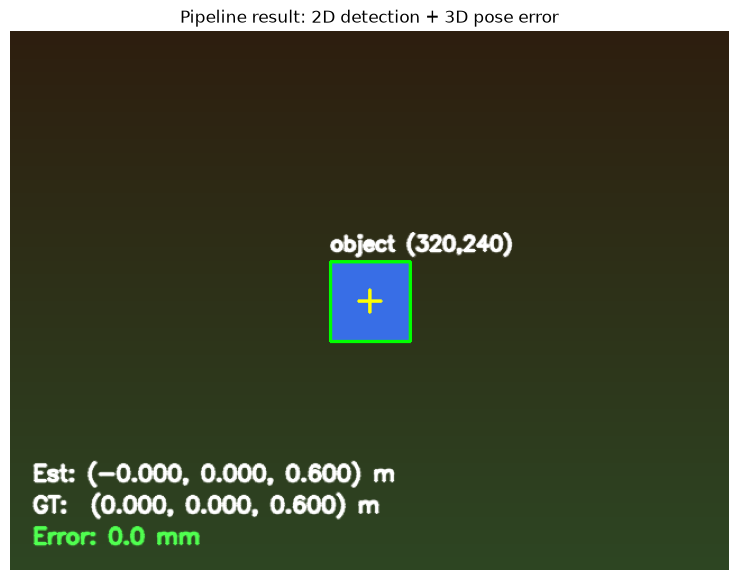

In [5]:
vis = draw_detection(rgb, detection)
vis = draw_3d_error(vis, estimated, gt_pose, error_m=error_m)

plt.figure(figsize=(10, 7))
plt.imshow(vis)
plt.title("Pipeline result: 2D detection + 3D pose error")
plt.axis("off")
plt.show()

## Open3D point cloud visualization

Side-by-side mask overlay and zoomed 3D point cloud. Saves `assets/demo/point_cloud_3d.png`.

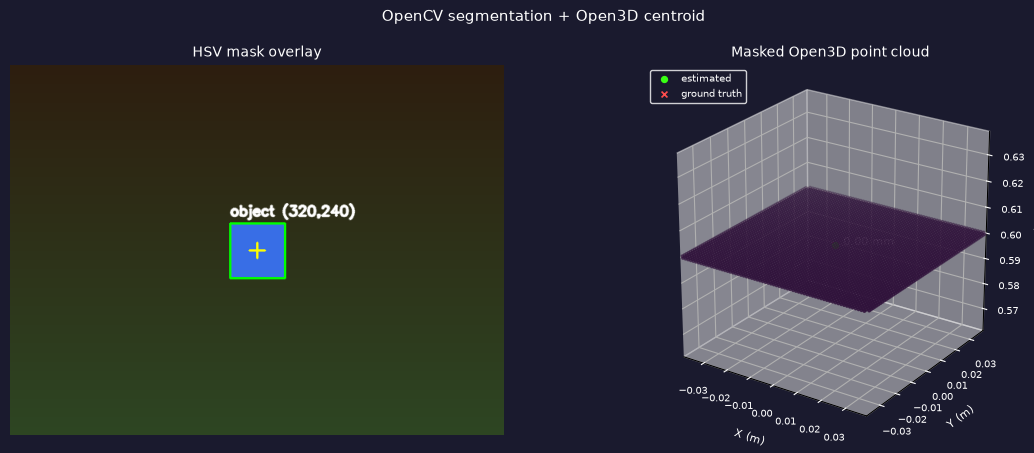

In [6]:
import os

from evals.metrics import show_mask_point_cloud

if detection is not None and estimated is not None:
    demo_dir = os.path.join(PROJECT_ROOT, "assets", "demo")
    os.makedirs(demo_dir, exist_ok=True)
    show_mask_point_cloud(
        rgb,
        detection,
        pose_estimator,
        depth,
        estimated,
        gt_pose,
        error_m=error_m,
        path=os.path.join(demo_dir, "point_cloud_3d.png"),
    )
else:
    print("Skip point-cloud figure: detection or pose missing")

## Benchmark

100 passes on the same frame — quick throughput sanity check, not camera/sim latency. For noise/occlusion sweeps use `evals.ipynb`.

In [7]:
import time

N = 100
t0 = time.perf_counter()
for _ in range(N):
    d = detector.detect(rgb)
    if d:
        pose_estimator.estimate(depth, d.center_px, mask=d.mask)
elapsed = time.perf_counter() - t0
print(f"Pipeline FPS (detect + pose): {N / elapsed:.1f}")

Pipeline FPS (detect + pose): 315.2
